In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
from liesel_ptm.sim.create_data import generate_data, loc_fn, scale_fn, generate_show_data
import liesel_ptm.sim.sim_ptm_onion as sim

import liesel_ptm as ptm
import plotnine as p9
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
key = jax.random.PRNGKey(43)
k1, k2, k3 = jax.random.split(key, 3)
shape = ptm.sample_shape(k1, nshape=15, scale=0.5).sample

In [4]:
df = generate_data(k2, shape=shape, nobs=500, loc_fn=loc_fn, scale_fn=scale_fn, ncov=4)
df_show = generate_show_data(shape=shape, values=(-1.0, 0.0, 1.0), index=3, loc_fn=loc_fn, scale_fn=scale_fn, ncov=4)


In [5]:
df_test = generate_data(k3, shape=shape, nobs=500, loc_fn=loc_fn, scale_fn=scale_fn, ncov=4)

In [6]:
df.head()

,y,y_std,z,z_deriv,log_prob,pdf,cdf,loc,scale,std_log_prob,...,fx2_loc,fx3_loc,fx0_scale,fx1_scale,fx2_scale,fx3_scale,x0,x1,x2,x3
0,10.206942,2.232632,1.744665,0.691033,-2.810431,0.060179,0.959478,5.960731,1.901886,-2.167585,...,4.668360,-2.191310,0.467730,0.338821,1.651539,-0.979292,0.467730,0.736472,-1.596650,-0.886242
1,0.908254,-0.133289,0.276225,0.792628,-1.189489,0.304377,0.608812,1.080569,1.292790,-0.932687,...,0.865345,-2.984703,1.487457,-0.755269,0.306136,-1.333857,1.487457,-0.202309,-0.980809,-1.728712
2,-4.636152,-0.181742,0.225912,1.698255,-0.414855,0.660436,0.589364,-4.523591,0.619348,-0.893943,...,-4.262245,-2.757971,-0.267288,0.127271,-1.507867,-1.232531,-0.267288,0.609090,1.679173,-1.231946
3,-4.448695,-0.875538,-1.201572,5.528967,0.069177,1.071625,0.114765,-3.870870,0.659965,-0.346391,...,-2.442300,-2.991808,-0.284808,-0.641472,-0.864020,-1.337032,-0.284808,-0.038018,-0.563385,-1.751841
4,-3.748631,0.267151,0.631991,0.947866,-1.172188,0.309689,0.736304,-3.953309,0.766147,-1.438570,...,-3.871760,-2.927217,1.289491,-0.886456,-1.369724,-1.308167,1.289491,-0.544298,1.754291,-1.551498


In [7]:
df_show.head()

,y,y_std,z,z_deriv,log_prob,pdf,cdf,loc,scale,std_log_prob,std_pdf,x0,x1,x2,x3
0,-2.192809,-1.781953,-4.000000,2.696191,-7.927097,0.000361,0.000032,-0.497307,0.951486,-7.976828,0.000343,0.0,0.0,0.0,-1.0
1,-2.177814,-1.766193,-3.959799,2.664938,-7.778734,0.000419,0.000038,-0.497307,0.951486,-7.828465,0.000398,0.0,0.0,0.0,-1.0
2,-2.162625,-1.750230,-3.919598,2.627469,-7.634546,0.000483,0.000044,-0.497307,0.951486,-7.684277,0.000460,0.0,0.0,0.0,-1.0
3,-2.147199,-1.734017,-3.879397,2.583364,-7.494708,0.000556,0.000052,-0.497307,0.951486,-7.544438,0.000529,0.0,0.0,0.0,-1.0
4,-2.131486,-1.717503,-3.839196,2.532285,-7.359506,0.000637,0.000062,-0.497307,0.951486,-7.409236,0.000606,0.0,0.0,0.0,-1.0


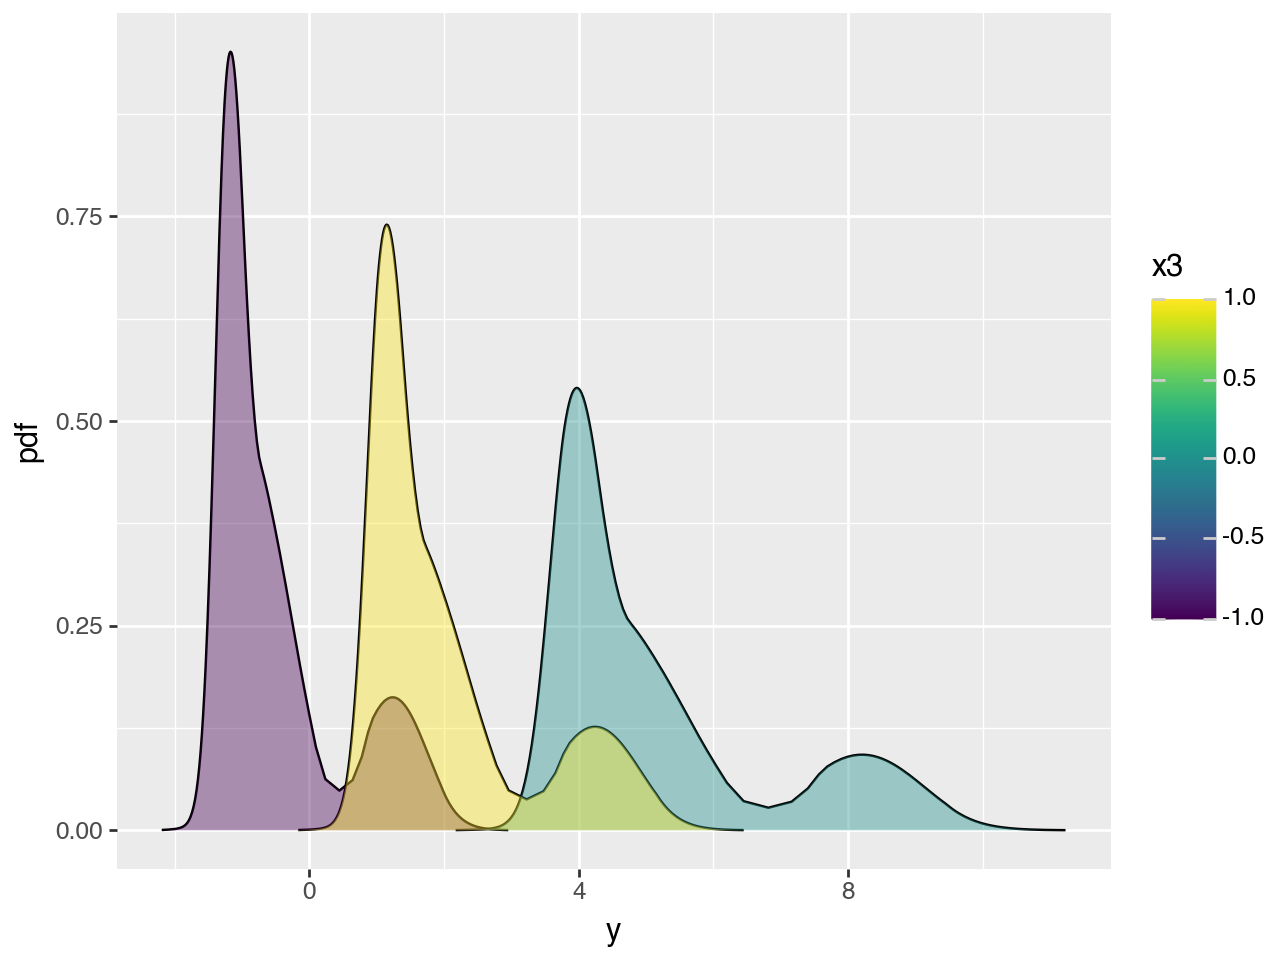

In [8]:
(
    p9.ggplot(df_show)
    + p9.aes("y", "pdf", group="x3")
    + p9.geom_line()
    + p9.geom_ribbon(p9.aes(ymin=0.0, ymax="pdf", fill="x3"), alpha=0.4)
)

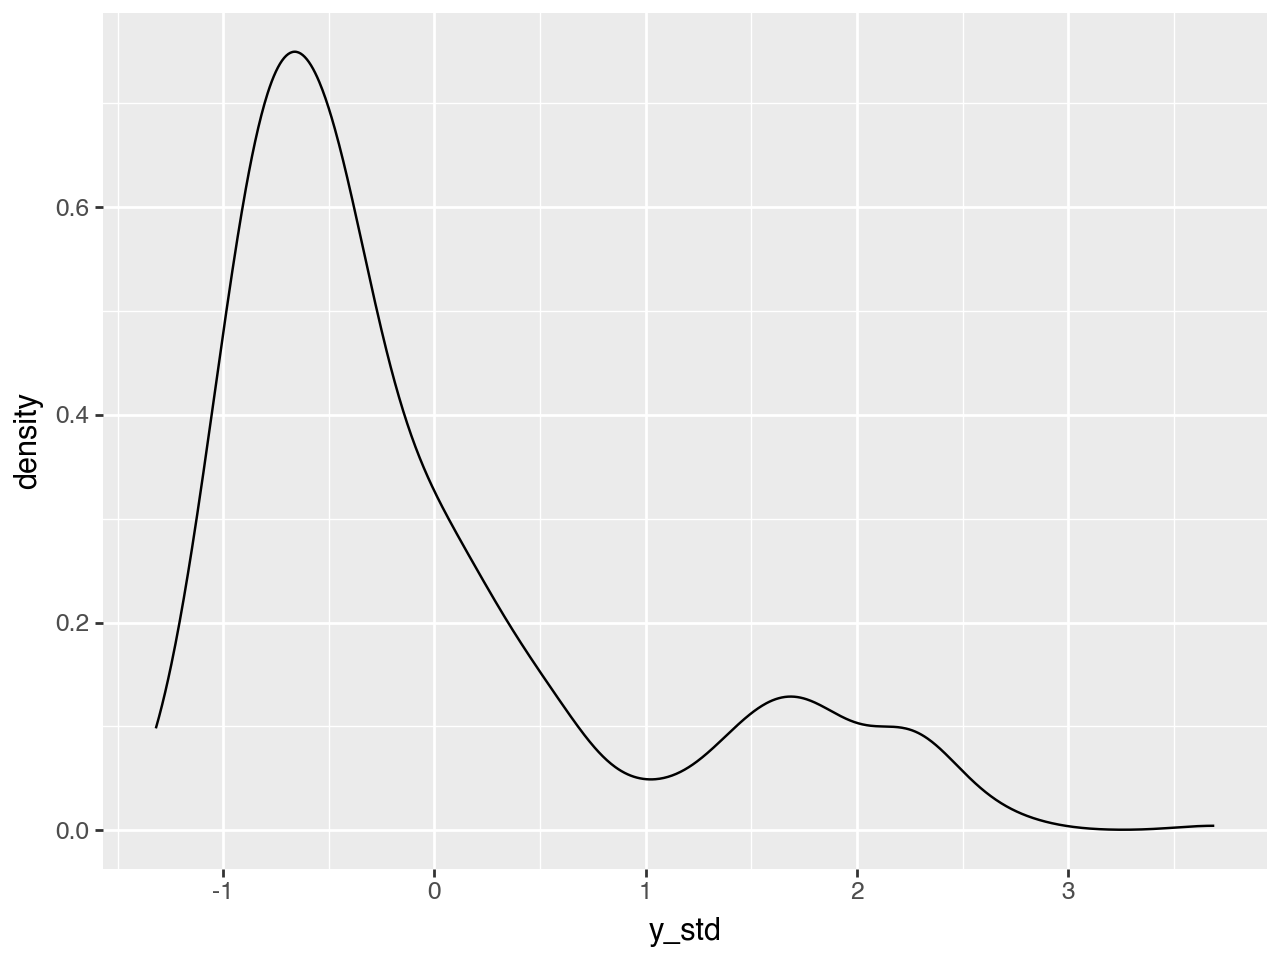

In [9]:
(
    p9.ggplot(df)
    + p9.aes("y_std")
    + p9.geom_density()
)

In [10]:
model = sim.model_setup(
    df, 
    prior_tau2_covariates=(ptm.VarInverseGamma, {"value": 1.0, "concentration": 1.0, "scale":0.01}),
    prior_tau2_normalization=(ptm.VarInverseGamma, {"value": 1.0, "concentration": 1.0, "scale":0.01}),
    scale_terms=True,
    nshape=30,
    centered=False,
    scaled=False
)

liesel_ptm.model - INFO - Optimizing location and scale parameters.
liesel_ptm.model - INFO - Building model graph. No changes to the model can be made after this step.
Training loss: 677.255, Validation loss: 677.255:   8%|▊         | 822/9999 [00:32<03:31, 43.49it/s]   liesel_ptm.model - INFO - Optimizing location and scale parameters finished after 822 iterations.


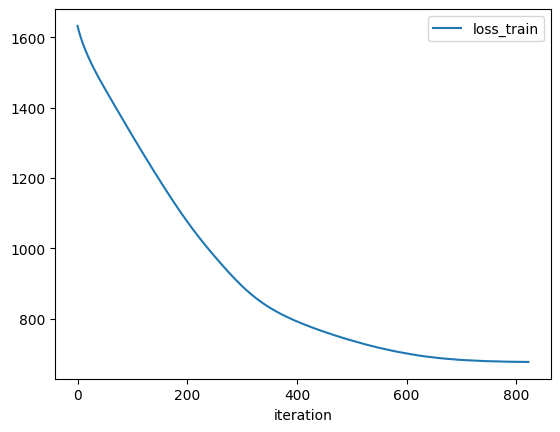

In [11]:
res1a = model.optimize_locscale(patience=10, max_iter=10_000, include_hyperparameters=True)
ptm.history_to_df(res1a.history)[["loss_train", "iteration"]].plot("iteration")
plt.show()

In [12]:
res1b = res1a

In [13]:
# res1b = model.optimize_locscale(patience=10, max_iter=10_000, include_loc=False)
# ptm.history_to_df(res1b.history)[["loss_train", "iteration"]].plot("iteration")
# plt.show()

In [14]:
res2 = model.optimize_transformation(patience=10, max_iter=10_000, include_hyperparameters=True)

liesel_ptm.model - INFO - Optimizing transformation parameters.
Training loss: 521.666, Validation loss: 521.666:   5%|▌         | 509/9999 [00:43<03:07, 50.61it/s] liesel_ptm.model - INFO - Optimizing transformation parameters finished after 509 iterations.


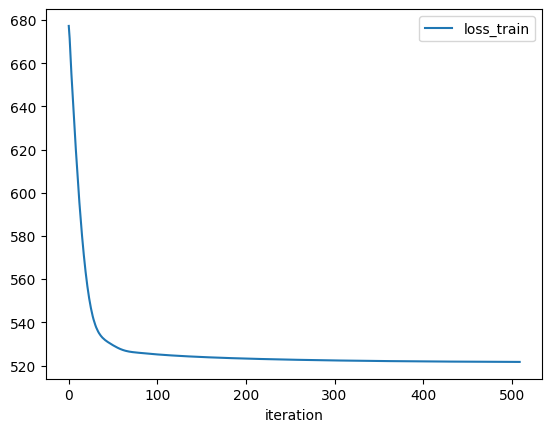

In [15]:
ptm.history_to_df(res2.history)[["loss_train", "iteration"]].plot("iteration")
plt.show()

In [16]:
mdist = model.init_dist(res1a.position | res1b.position | res2.position)
res, _ = mdist.transformation_and_logdet_parametric(model.response.value)

liesel_ptm.model - INFO - Fixed value of x0_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x1_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x2_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x3_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x0_scale to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x1_scale to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x2_scale to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x3_scale to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x0_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x1_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x2_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x3_loc to corresponding node value.
liesel_ptm.model - INFO - Fixed value of x0_scale to corresponding n

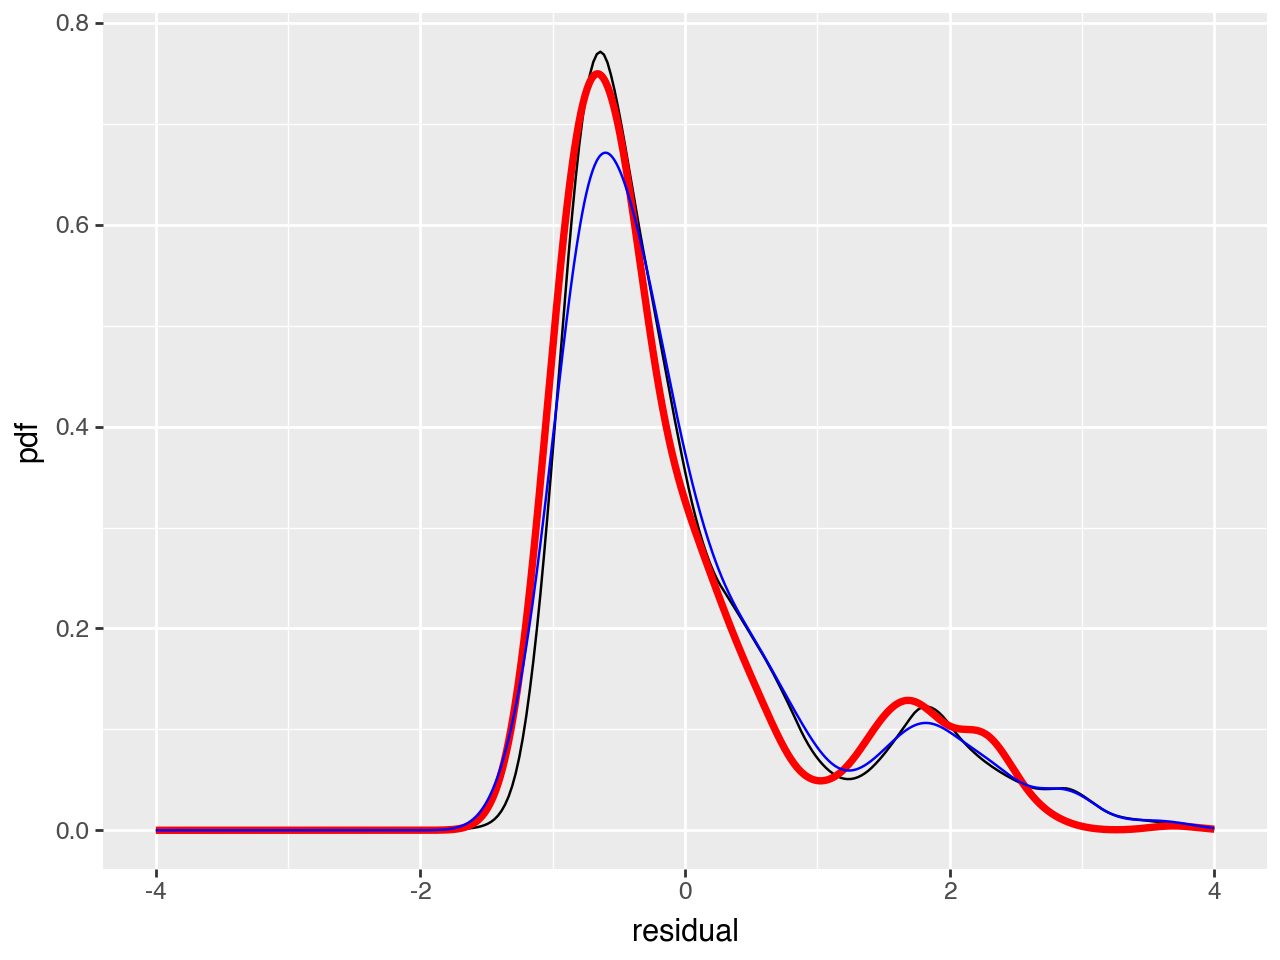

In [17]:
dist = model.dist_class(model.knots.knots, model.coef.value, loc=0.0, scale=1.0)
residual = jnp.linspace(-4, 4, 301)
pdf = dist.prob(residual)
z, _ = dist.transformation_and_logdet(residual)



df_pdf = pd.DataFrame({"residual": residual, "pdf": pdf, "z": z})

(
    p9.ggplot(df_pdf)
    + p9.geom_line(p9.aes("residual", "pdf"))
    + p9.geom_density(p9.aes("y_std"), data = df, color="red", size=1.5)
    + p9.geom_density(
        p9.aes("res"),
        data=pd.DataFrame({"res": res}),
        color="blue"
    )
)

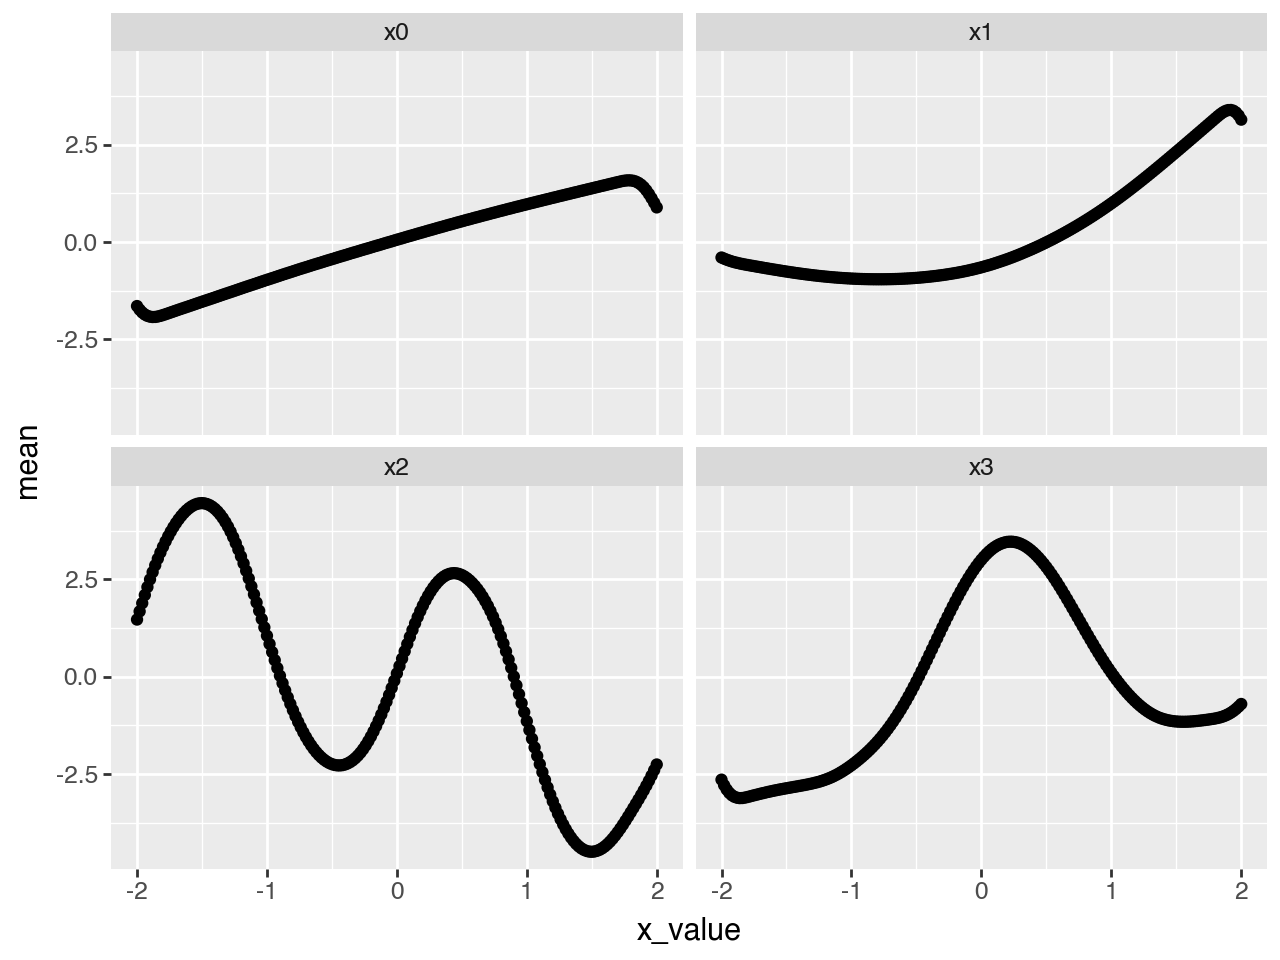

In [18]:
x0_loc = model.loc_model.x0_loc.summarise_by_quantiles(
    {"x0_loc_coef": jnp.expand_dims(res1a.position["x0_loc_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x0_loc["x"] = "x0"

x1_loc = model.loc_model.x1_loc.summarise_by_quantiles(
    {"x1_loc_coef": jnp.expand_dims(res1a.position["x1_loc_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x1_loc["x"] = "x1"

x2_loc = model.loc_model.x2_loc.summarise_by_quantiles(
    {"x2_loc_coef": jnp.expand_dims(res1a.position["x2_loc_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x2_loc["x"] = "x2"

x3_loc = model.loc_model.x3_loc.summarise_by_quantiles(
    {"x3_loc_coef": jnp.expand_dims(res1a.position["x3_loc_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x3_loc["x"] = "x3"

loc_df = pd.concat([x0_loc, x1_loc, x2_loc, x3_loc])

(
    p9.ggplot(loc_df)
    + p9.aes("x_value", "mean")
    + p9.geom_point()
    + p9.facet_wrap("~x")
)

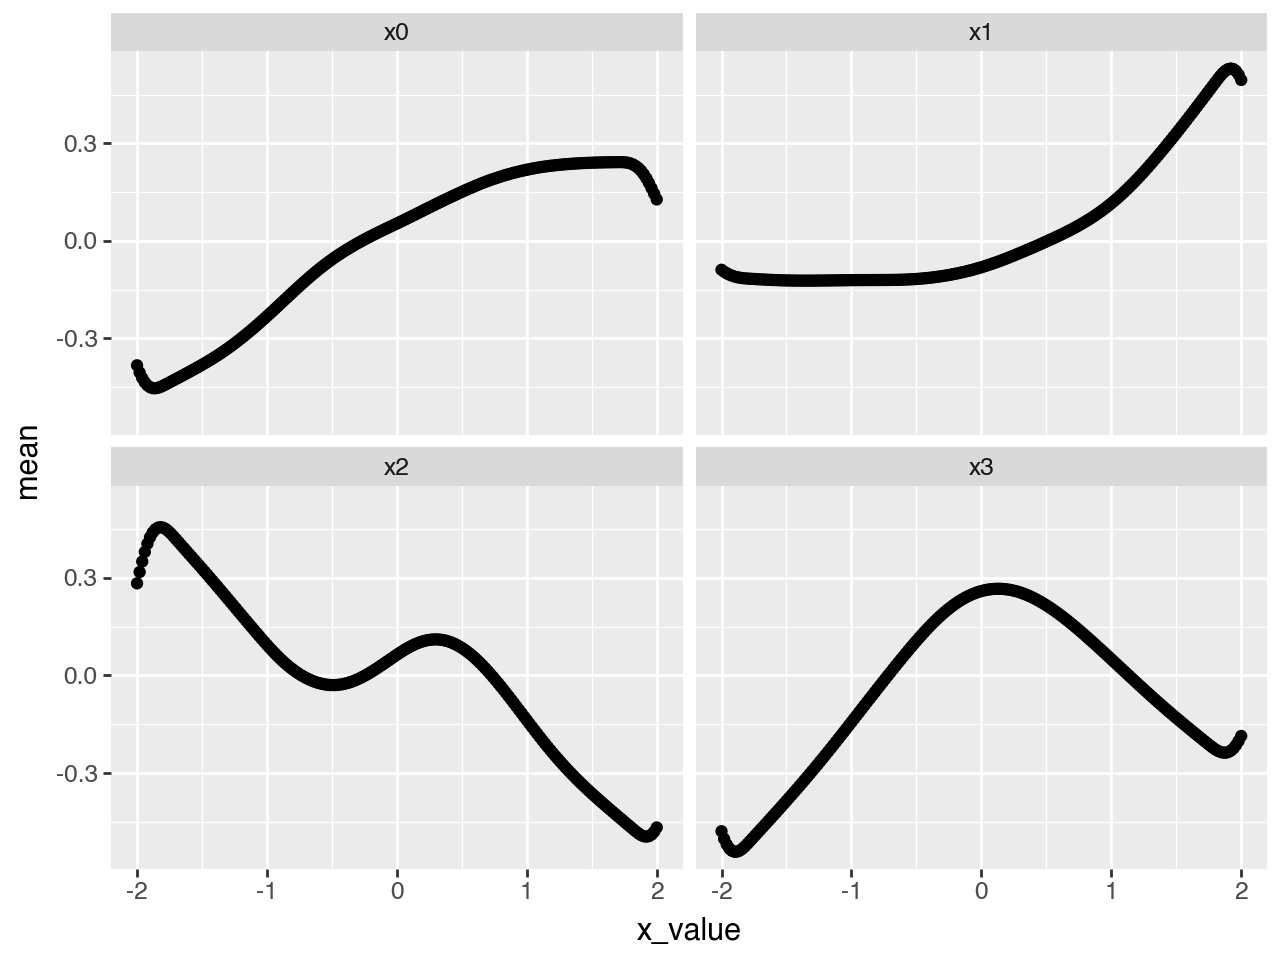

Training loss: 521.666, Validation loss: 521.666:   5%|▌         | 509/9999 [00:56<03:07, 50.61it/s]

In [19]:
x0_scale = model.log_scale_model.x0_scale.summarise_by_quantiles(
    {"x0_scale_coef": jnp.expand_dims(res1b.position["x0_scale_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x0_scale["x"] = "x0"

x1_scale = model.log_scale_model.x1_scale.summarise_by_quantiles(
    {"x1_scale_coef": jnp.expand_dims(res1b.position["x1_scale_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x1_scale["x"] = "x1"

x2_scale = model.log_scale_model.x2_scale.summarise_by_quantiles(
    {"x2_scale_coef": jnp.expand_dims(res1b.position["x2_scale_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x2_scale["x"] = "x2"

x3_scale = model.log_scale_model.x3_scale.summarise_by_quantiles(
    {"x3_scale_coef": jnp.expand_dims(res1b.position["x3_scale_coef"], 0)},
    x=jnp.linspace(-2, 2, 201),
    axis=0
)
x3_scale["x"] = "x3"

scale_df = pd.concat([x0_scale, x1_scale, x2_scale, x3_scale])

(
    p9.ggplot(scale_df)
    + p9.aes("x_value", "mean")
    + p9.geom_point()
    + p9.facet_wrap("~x")
)